# Compare Loop 3 and Loop 2.5 on Monocyte Enrichment.

## Prepare the Notebook.

### Import the Libraries.

In [15]:
import joblib
import os
import sys
import yaml

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
import seaborn as sns
from tqdm import tqdm

sys.path.insert(0, "../../../../shared_utils")
from experiment_utils import manual_filtering

### Read Annotation Configurations from Loop 2.5.

In [16]:
config2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config2_path, "r") as fb:
    annot2_dict = yaml.safe_load(fb)
protocol_cols2 = annot2_dict["protocol_columns"]
resc_protocol_cols2 = [f"{c}:rescaled" for c in protocol_cols2]

### Read Annotation Configurations from Loop 3.

In [17]:
config3_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(config3_path, "r") as fb:
    annot3_dict = yaml.safe_load(fb)
protocol_cols3 = annot3_dict["protocol_columns"]
resc_protocol_cols3 = [f"{c}:rescaled" for c in protocol_cols3]

### Get Additional Molecules from Loop 3.

In [18]:
additional_molecules = list(set(protocol_cols3).difference(set(protocol_cols2)))
additional_molecules

['mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'il7_[ng_ml]']

### Read Constraints Configurations from Loop 3.

In [19]:
constraints3_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(constraints3_config_path, "r") as fb:
    constraints3_config = yaml.safe_load(fb)
ubound3_dict = constraints3_config["ubound_dict"]
lbound3_dict = constraints3_config["lbound_dict"]


## Read Optimization Results.

### Define Function to Read Results Directory in a Parallelized Way.

In [20]:
def get_masked_opt_df(
    res_base_dir
):
    all_runs = []

    opt_modes_list = os.listdir(res_base_dir)

    for opt_leaf_dir in opt_modes_list:
        opt_dir = os.path.join(res_base_dir, opt_leaf_dir)
        cts_list = os.listdir(opt_dir)

        for ct_leaf_dir in cts_list:
            ct_dir = os.path.join(opt_dir, ct_leaf_dir)
            runs_list = os.listdir(ct_dir)

            for run_leaf_dir in runs_list:
                run_dir = os.path.join(ct_dir, run_leaf_dir)
                csv_path = os.path.join(run_dir, "candidates.csv")

                masked_eval_dir = os.path.join(run_dir, "masked_eval")
                masked_csv_path = os.path.join(masked_eval_dir, "masked_ct_props.csv")

                if not os.path.isfile(masked_csv_path):
                    continue

                all_runs.append(
                    {
                        "target_ct": ct_leaf_dir,
                        "run_id": run_leaf_dir,
                        "opt_id": opt_leaf_dir,
                        "csv_path": csv_path,
                        "masked_csv_path": masked_csv_path,
                    }
                )

    def _load_run(run_dict):
        target_ct = run_dict["target_ct"]
        run_id = run_dict["run_id"]
        opt_id = run_dict["opt_id"]
        csv_path = run_dict["csv_path"]
        masked_csv_path = run_dict["masked_csv_path"]

        df = pd.read_csv(csv_path)
        df["run_id"] = run_id
        df["opt_id"] = opt_id
        df["target_ct"] = target_ct

        df_masked = pd.read_csv(masked_csv_path)
        df_masked = df_masked.add_suffix(":masked")

        # Column‑wise concatenation (assumes rows are aligned)
        merged = pd.concat([df, df_masked], axis=1)
        return merged
        
    n_jobs = 100
    data = joblib.Parallel(n_jobs=n_jobs)(joblib.delayed(_load_run)(run_dict) for run_dict in all_runs)
    return pd.concat(data, ignore_index=True)

### Read Optimization Data from Looop 3.

In [21]:
res_base_dir3 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate"
opt_df3 = get_masked_opt_df(res_base_dir3)
opt_df3

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,MPP_MgkEry_prop:masked,MgKEryPro1_prop:masked,MgKEryPro2_prop:masked,ProB_prop:masked,earlyMPP_prop:masked,late_MgkPro_prop:masked,preProB_prop:masked,pre_cDC1_prop:masked,pre_cDC2_prop:masked,sample_id:masked
0,CD16Mono:2026-06-27_13-56-52_e6fdaccf:0,8.175344,0.870487,4.591022,18.757362,0.605229,0.236549,0.000000,0.000000,0.000000,...,0.002524,0.142040,0.092619,0.000143,0.001702,0.000753,0.000214,0.006242,0.004069,CD16Mono:2026-06-27_13-56-52_e6fdaccf:0
1,CD16Mono:2026-06-27_13-56-52_e6fdaccf:1,8.601083,0.957379,46.283240,246.589510,0.440352,50.364555,6.461353,0.000000,2.597389,...,0.007785,0.047646,0.005511,0.000154,0.002337,0.000116,0.000368,0.004670,0.008217,CD16Mono:2026-06-27_13-56-52_e6fdaccf:1
2,CD16Mono:2026-06-27_13-56-52_e6fdaccf:2,9.473975,0.952254,267.945340,0.000000,0.122417,50.568176,7.458750,0.677545,0.000000,...,0.001696,0.255476,0.000038,0.000192,0.002482,0.008033,0.000955,0.006095,0.000790,CD16Mono:2026-06-27_13-56-52_e6fdaccf:2
3,CD16Mono:2026-06-27_13-56-52_e6fdaccf:3,10.014435,1.487196,7.917052,268.476530,0.650496,51.108850,0.531202,0.000000,12.939014,...,0.013318,0.075095,0.007400,0.000028,0.001022,0.000151,0.000249,0.007310,0.005180,CD16Mono:2026-06-27_13-56-52_e6fdaccf:3
4,CD16Mono:2026-06-27_13-56-52_e6fdaccf:4,10.276027,2.532859,773.195200,1147.167200,0.000000,51.491257,0.049060,0.337223,7.699808,...,0.000635,0.045392,0.000309,0.000365,0.000734,0.000319,0.000294,0.001825,0.003788,CD16Mono:2026-06-27_13-56-52_e6fdaccf:4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,CD14Mono:2026-06-26_21-24-45_96c03b38:45,9.912007,1.232016,323.654360,1126.959400,0.343544,34.910770,0.000000,0.652988,0.000000,...,0.051748,0.040403,0.000385,0.000629,0.003404,0.000206,0.002374,0.000472,0.039035,CD14Mono:2026-06-26_21-24-45_96c03b38:45
5996,CD14Mono:2026-06-26_21-24-45_96c03b38:46,9.346156,2.468216,719.650600,0.210491,0.855513,9.700544,0.000000,0.034562,0.279661,...,0.017159,0.065298,0.000962,0.000470,0.001949,0.015232,0.003514,0.002929,0.003876,CD14Mono:2026-06-26_21-24-45_96c03b38:46
5997,CD14Mono:2026-06-26_21-24-45_96c03b38:47,10.061170,1.765604,758.440700,984.091000,0.579085,27.801916,0.000000,0.000000,0.000000,...,0.102998,0.048651,0.001345,0.000105,0.004254,0.000324,0.003630,0.001046,0.009435,CD14Mono:2026-06-26_21-24-45_96c03b38:47
5998,CD14Mono:2026-06-26_21-24-45_96c03b38:48,10.081996,2.048814,758.927860,0.000000,1.718140,50.426730,0.000000,0.000000,0.000000,...,0.137596,0.045449,0.002010,0.001096,0.004349,0.000457,0.004898,0.000835,0.005598,CD14Mono:2026-06-26_21-24-45_96c03b38:48


## Filter Optimization Data on Experimental Constraints.

### Define Function to Filter Optimization Data Based on Experimental Constraints.

In [22]:
def filter_opt_results(candidates_df, lbound_dict, ubound_dict,  margin = 0.1):
    # ----  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col, col_ubound in ubound_dict.items():
        # get col bounds
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df

### Filter Optimization Data from Loop 3.

In [23]:
opt_df3 = filter_opt_results(opt_df3, lbound3_dict, ubound3_dict)
opt_df3_filt = opt_df3[opt_df3["passes_constraints:all"]]
opt_df3_filt.shape[0] / opt_df3.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 6000 ---
			 --- Number Currently Accepted Solutions 5990 ---
			 --- Number of Solution Satisfying Upper Bound 5990 ---
			 --- Number of Solution Satisfying Lower Bound 6000 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 5990 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 6000 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 5990 ---
			 --- Number Currently Accepted Solutions 5905 ---
			 --- Number of Solution Satisfying Upper Bound 5914 ---
			 --- Number of Solution Satisfying Lower Bound 6000 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 5905 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 5990 ---
		---- Processing Column um171_[nm] -> U: 1120.0, L: 0.0 ----


0.9223333333333333

### Construct Data Frame.

In [25]:
target_ct_values = opt_df3_filt.target_ct.unique()

all_records = []
for ct in target_ct_values:
    ct_col = f"{ct}_prop"
    ct_col_masked = f"{ct}_prop:masked"

    ct_probs = opt_df3_filt[ct_col].values
    ct_probs_masked = opt_df3_filt[ct_col_masked].values
    delta_ct_prob = ct_probs - ct_probs_masked

    mol_values = {mol:opt_df3_filt[mol].values for mol in additional_molecules}

    for idx in range(ct_probs.shape[0]):
        all_records.append(
            {
                f"Target Cell Type": ct,
                f"{ct}% Original": ct_probs[idx],
                f"{ct}% Masked": ct_probs_masked[idx],
                f"Delta {ct}%": delta_ct_prob[idx],
                **{mol:val[idx] for mol, val in mol_values.items()}
            }
        )

masked_eval_df = pd.DataFrame(all_records)
masked_eval_df

,Target Cell Type,CD16Mono% Original,CD16Mono% Masked,Delta CD16Mono%,mcsf_[ng_ml],ly_cocktail_[ul/well],il7_[ng_ml],CD14Mono% Original,CD14Mono% Masked,Delta CD14Mono%
0,CD16Mono,0.010942,0.022778,-0.011836,0.000000,0.000000,0.000000,NaN,NaN,NaN
1,CD16Mono,0.018922,0.013601,0.005320,0.450948,0.000000,0.000000,NaN,NaN,NaN
2,CD16Mono,0.127409,0.084305,0.043104,0.352460,0.000000,0.078338,NaN,NaN,NaN
3,CD16Mono,0.020137,0.024635,-0.004499,0.053482,0.000000,0.000000,NaN,NaN,NaN
4,CD16Mono,0.327201,0.004826,0.322375,20.211111,0.287323,0.000740,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
11063,CD14Mono,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.002014,0.002883,-0.000869
11064,CD14Mono,NaN,NaN,NaN,0.022596,0.011075,0.000000,0.020122,0.022011,-0.001889
11065,CD14Mono,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.011410,0.003415,0.007995
11066,CD14Mono,NaN,NaN,NaN,0.163346,0.000000,0.000000,0.016062,0.010269,0.005792


### Plot Reduction for Monocytes.

CD16Mono: r = 0.919, p = 0
Saved output/CD16Mono_scatter.png


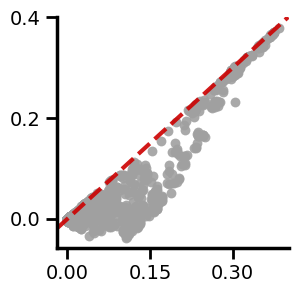

CD14Mono: r = 0.999, p = 0
Saved output/CD14Mono_scatter.png


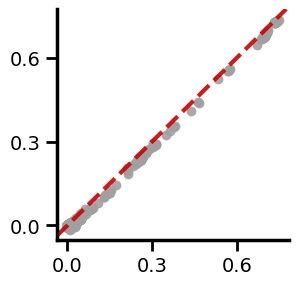

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
# Colorblind-friendly palette
dot_color = "#A0A0A0"      # magenta‑purple
line_color = "#CC0000"    # grey line (or choose any from the previous list)
# Your list of cell types to plot
# target_ct_values = [...]   # e.g. ["CD14Mono", "CD16Mono", ...]
for ct in target_ct_values:
    x_col = f"{ct}% Original"
    y_col = f"Delta {ct}%"

    # Drop NaNs so pearsonr doesn't choke
    valid = masked_eval_df[[x_col, y_col]].dropna()
    r, p = pearsonr(valid[x_col], valid[y_col])

    # Create figure and axes
    fig, ax = plt.subplots(figsize=(3, 3))
    # Scatter plot
    sns.scatterplot(
        data=masked_eval_df,
        x=x_col,
        y=y_col,
        s=50,
        color=dot_color,
        # edgecolor="black",
        linewidth=0.0,
        alpha=0.9,
        ax=ax
    )
    # y = x reference line
    ax.axline((0, 0), slope=1, color=line_color, linestyle='--',
              linewidth=3, alpha=0.9)
    # Strip all annotations, keep only the bare axes
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel('')
    if ax.get_legend():
        ax.get_legend().remove()
    # Set exactly 3 tick markers per axis
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    # Keep the y=x line at true 45°
    # ax.set_aspect('equal')
    # --- Make the axes (spines) themselves thicker ---
    for spine in ax.spines.values():
        spine.set_linewidth(2.5) 
    ax.tick_params(axis='both', which='major', labelsize=14, length=8, width=2)
    # Remove top and right spines
    sns.despine(ax=ax)
    # --- SAVE the figure with high DPI instead of showing it ---
    filename = f"output/{ct}_scatter.png"          # or use a full path like f"figures/{ct}.png"
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"{ct}: r = {r:.3f}, p = {p:.3g}")
    print(f"Saved {filename}")
    # Close the figure to release memory
    plt.show()
    plt.close(fig)
# Optional: if you still want to see one of them on screen, you can use plt.show()
# inside the loop or after, but typically you'd comment it out.
